In [39]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
clientes_df = pd.read_csv('clientes.csv')
pedidos_df = pd.read_csv('pedidos.csv')
entrega_df = pd.read_csv('entregas.csv')

In [4]:
clientes_df.head(5)

,id,nome,data_entrada,segmento,estado,cidade
0,1,Diego Nascimento,2024-03-30,Beleza,PB,Gomes
1,2,Cecília Campos,2024-06-07,Casa,PA,Lopes dos Dourados
2,3,Rafaela Souza,2024-10-06,Eletrônicos,MS,Moraes
3,4,Ana Lívia Sales,2024-09-03,Beleza,SC,Barbosa
4,5,Yuri Mendes,2024-10-25,Alimentos,AL,Ramos


In [5]:
pedidos_df.head(5)

,id,id_cliente,data_pedido,valor,canal_venda
0,1,57,2025-02-21,190.74,WhatsApp
1,2,156,2025-02-12,152.10,Marketplace
2,3,25,2025-03-11,1411.59,Marketplace
3,4,52,2024-12-17,328.56,WhatsApp
4,5,147,2024-12-07,122.34,Marketplace


In [6]:
entrega_df.head(5)

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou
1,2,Jadlog,Entregue,2025-02-20,2025-02-18,NaN
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha
3,4,Correios,Entregue,2024-12-17,2024-12-19,NaN
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha


Análise de clientes com problemas recorrentes de entrega

In [8]:
rel_entrega_pedido = entrega_df.merge(pedidos_df[['id', 'id_cliente']], left_on='id_pedido', right_on='id')
rel_entrega_pedido

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id,id_cliente
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57
1,2,Jadlog,Entregue,2025-02-20,2025-02-18,NaN,2,156
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25
3,4,Correios,Entregue,2024-12-17,2024-12-19,NaN,4,52
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147
...,...,...,...,...,...,...,...,...
995,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133
996,997,Total Express,Entregue,2024-10-10,2024-10-06,NaN,997,69
997,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120
998,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53


In [9]:
filtro_problemas = ['Atrasado','Extraviado','Devolvido']

pedidos_com_problemas = rel_entrega_pedido[rel_entrega_pedido['status'].isin(filtro_problemas)]
pedidos_com_problemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id,id_cliente
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147
6,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado,7,19
8,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha,9,110
...,...,...,...,...,...,...,...,...
994,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha,995,17
995,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133
997,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120
998,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53


Relação de NPS/recompras com cliente com problemas

In [12]:
clientes_com_problemas = pedidos_com_problemas.groupby('id_cliente').size().reset_index(name="qtd_problemas").sort_values(by='qtd_problemas',ascending=False)
clientes_com_problemas.head()

,id_cliente,qtd_problemas
137,186,7
13,17,5
74,103,4
2,6,4
149,198,4


In [13]:
nps_df = pd.read_csv('nps.csv')

In [14]:
nps_df

,id_cliente,data_resposta,nota,comentario
0,1,2024-06-29,9,Necessitatibus nulla sit expedita nostrum recu...
1,2,2024-06-13,10,Eaque ullam mollitia eaque earum ratione totam...
2,2,2025-03-16,8,Animi reiciendis commodi itaque quidem asperio...
3,3,2024-09-07,8,Voluptas ex ut esse.
4,3,2025-05-07,0,Porro expedita doloribus ullam ab adipisci eius.
...,...,...,...,...
384,198,2024-11-16,3,Debitis dolores optio officiis enim tenetur ip...
385,198,2024-11-04,9,Incidunt quisquam vitae unde aspernatur ad inc...
386,199,2024-06-21,1,Cupiditate placeat tenetur dicta atque occaeca...
387,200,2024-08-11,10,Maxime aspernatur dolore vero aut voluptate la...


In [20]:
rel_clientesProblemas_nps = clientes_com_problemas.merge(nps_df, on='id_cliente', how='left')
rel_clientesProblemas_nps

,id_cliente,qtd_problemas,data_resposta,nota,comentario
0,186,7,2024-10-02,10,Similique rem saepe ratione est eos nulla debi...
1,186,7,2024-10-05,8,Illum quibusdam recusandae praesentium optio f...
2,17,5,2024-08-10,4,Sunt iure exercitationem magni est nobis praes...
3,103,4,2024-11-05,0,Minima illo temporibus nemo possimus accusamus...
4,103,4,2024-09-06,6,Quo quos commodi occaecati ducimus fuga cum si...
...,...,...,...,...,...
295,61,1,2024-08-19,2,Nisi est consequuntur culpa.
296,61,1,2024-09-20,2,Iure maiores quibusdam tenetur corporis pariat...
297,61,1,2024-09-14,5,Dolores neque quasi asperiores tenetur.
298,3,1,2024-09-07,8,Voluptas ex ut esse.


In [25]:
def classificar_nps(nota):
    if nota >= 8:
        return "Bom"
    elif nota >= 5:
        return "Médio"
    else:
        return "Ruim"

In [26]:
rel_clientesProblemas_nps['classificacao'] = rel_clientesProblemas_nps['nota'].apply(classificar_nps)
rel_clientesProblemas_nps

,id_cliente,qtd_problemas,data_resposta,nota,comentario,classificacao
0,186,7,2024-10-02,10,Similique rem saepe ratione est eos nulla debi...,Bom
1,186,7,2024-10-05,8,Illum quibusdam recusandae praesentium optio f...,Bom
2,17,5,2024-08-10,4,Sunt iure exercitationem magni est nobis praes...,Ruim
3,103,4,2024-11-05,0,Minima illo temporibus nemo possimus accusamus...,Ruim
4,103,4,2024-09-06,6,Quo quos commodi occaecati ducimus fuga cum si...,Médio
...,...,...,...,...,...,...
295,61,1,2024-08-19,2,Nisi est consequuntur culpa.,Ruim
296,61,1,2024-09-20,2,Iure maiores quibusdam tenetur corporis pariat...,Ruim
297,61,1,2024-09-14,5,Dolores neque quasi asperiores tenetur.,Médio
298,3,1,2024-09-07,8,Voluptas ex ut esse.,Bom


In [27]:
rel_clientesProblemas_nps['classificacao'].value_counts()

classificacao
Ruim     133
Bom       93
Médio     74
Name: count, dtype: int64

In [29]:
pedidos_por_cliente = pedidos_df.groupby("id_cliente").size().reset_index(name="qtd_pedidos")
clientes_nps = rel_clientesProblemas_nps.merge(pedidos_por_cliente, on="id_cliente", how="left")
clientes_nps["fez_recompra"] = clientes_nps["qtd_pedidos"] > 1

clientes_nps["fez_recompra"].value_counts()

fez_recompra
True     296
False      4
Name: count, dtype: int64

Transportadoras mais associadas aos problemas

In [32]:
transportadoras_problemas = entrega_df['transportadora'][entrega_df['status'].isin(filtro_problemas)]
transportadoras_problemas.value_counts()

transportadora
Correios         78
Loggi            74
Total Express    68
Jadlog           60
Name: count, dtype: int64

Estados e segmentos com mais problemas

In [33]:
entregas_problemas = entrega_df[entrega_df['status'].isin(filtro_problemas)]
entregas_problemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha
6,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado
8,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha
...,...,...,...,...,...,...
994,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha
995,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou
997,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha
998,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado


In [34]:
rel_pedidos_entregaProblemas = entregas_problemas.merge(pedidos_df[['id','id_cliente']],left_on='id_pedido',right_on='id')
rel_pedidos_entregaProblemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id,id_cliente
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57
1,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25
2,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147
3,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado,7,19
4,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha,9,110
...,...,...,...,...,...,...,...,...
275,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha,995,17
276,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133
277,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120
278,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53


In [35]:
rel_cliente_entregaProblemas = rel_pedidos_entregaProblemas.merge(clientes_df[['id','estado','cidade','segmento']],left_on='id_cliente',right_on='id')
rel_cliente_entregaProblemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id_x,id_cliente,id_y,estado,cidade,segmento
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57,57,RR,Fogaça,Alimentos
1,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25,25,SP,da Cruz,Moda
2,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147,147,MA,Mendes,Moda
3,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado,7,19,19,RJ,Santos do Oeste,Alimentos
4,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha,9,110,110,PI,Correia do Norte,Moda
...,...,...,...,...,...,...,...,...,...,...,...,...
275,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha,995,17,17,PA,Cardoso do Sul,Alimentos
276,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133,133,RN,da Paz do Sul,Alimentos
277,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120,120,RN,da Costa Alegre,Alimentos
278,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53,53,RN,Araújo dos Dourados,Eletrônicos


In [36]:
problemas_Estado = rel_cliente_entregaProblemas.groupby('estado').size().reset_index(name='qtd_problemas').sort_values(by='qtd_problemas',ascending=False)
problemas_Estado

,estado,qtd_problemas
19,RN,33
4,BA,24
22,RS,17
13,PA,16
1,AL,16
3,AP,15
23,SC,15
11,MS,12
24,SE,11
5,CE,10


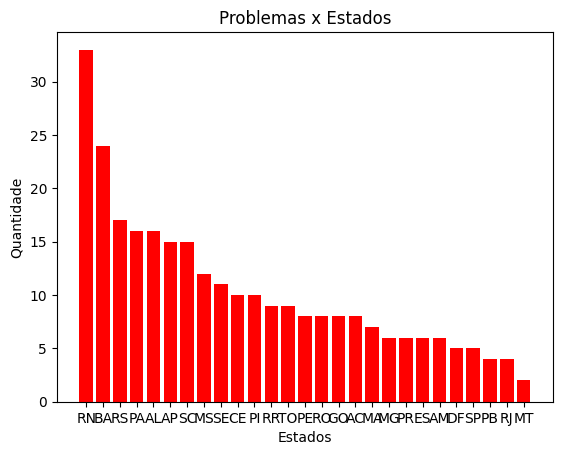

<Figure size 2500x2500 with 0 Axes>

In [ ]:
plt.bar(problemas_Estado['estado'], problemas_Estado['qtd_problemas'], color='r')
plt.xlabel('Estados')
plt.ylabel('Quantidade')
plt.title("Problemas x Estados")
plt.figure(figsize=(30,30))
plt.show()

In [37]:
problemas_Segmento= rel_cliente_entregaProblemas.groupby('segmento').size().reset_index(name='qtd_problemas').sort_values(by='qtd_problemas',ascending=False)
problemas_Segmento

,segmento,qtd_problemas
0,Alimentos,72
3,Eletrônicos,72
2,Casa,47
1,Beleza,45
4,Moda,44
